# Input-calibration VALIDATION

Validates the FC **command→achieved** transfer (body-rate + thrust) — derived from the phased
≥5-run input calibration — on **independent** data:

1. **Multi-axis maneuver** (1 run) — all rate axes commanded together, so it tests whether the
   per-axis gain+lag hold under **coupled** commands. Record to `validation_data/input_multi/`.
2. **Landing to touchdown** (1 run) — the real command profile, where the aggressive terminal
   maneuvers and the slow yaw loop actually bite.

**Input cal is a *dynamic* transfer**, so the headline metric is **LAG**, not just amplitude:
a gain≈1 with a 287 ms yaw lag is still a failing cal for control. Reuses
`aggregate_input_calibration.per_run_metrics` (cross-correlation gain + lag per axis).

In [1]:
import os, sys, glob, numpy as np, matplotlib.pyplot as plt
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'tools'))
import aggregate_input_calibration as aic   # per_run_metrics(run, return_series=True), AXES

def _latest(pat, fb=None):
    h = sorted(glob.glob(pat))
    if h: return h[-1]
    if fb:
        f = sorted(glob.glob(fb))
        if f: print(f'(no run in {pat}; falling back to {f[-1]})'); return f[-1]
    return None

# Independent validation runs (record with INPUT_CALIB_OUT_BASE=.../validation_data/input_multi):
MULTI_RUN   = _latest('../validation_data/input_multi/*', '../calibration_data/input/*')
LANDING_RUN = _latest('../validation_data/landing/*',     '../test_data/Landing_Test/*')
print('MULTI_RUN   =', MULTI_RUN)
print('LANDING_RUN =', LANDING_RUN)
AXLBL = {'wx': 'roll-rate ωx', 'wy': 'pitch-rate ωy', 'wz': 'yaw-rate ωz'}

MULTI_RUN   = ../validation_data/input_multi/Sat Jun  6 20-41-45 2026
LANDING_RUN = ../validation_data/landing/Sun Jun  7 00-08-38 2026


## 1 — Multi-axis validation: commanded vs achieved body rate (gain + LAG)

Per axis: Pearson r, cross-correlation **lag (ms)**, and amplitude **gain**. Watch ωz — its
loop is ~5× slower than roll/pitch.

=== MULTI-AXIS validation ===   Sat Jun  6 20-41-45 2026
  axis                r   lag_ms    gain
  roll-rate ωx     0.98     45.0   1.108
  pitch-rate ωy    0.98     45.0   1.067
  yaw-rate ωz      0.25    300.0   0.717


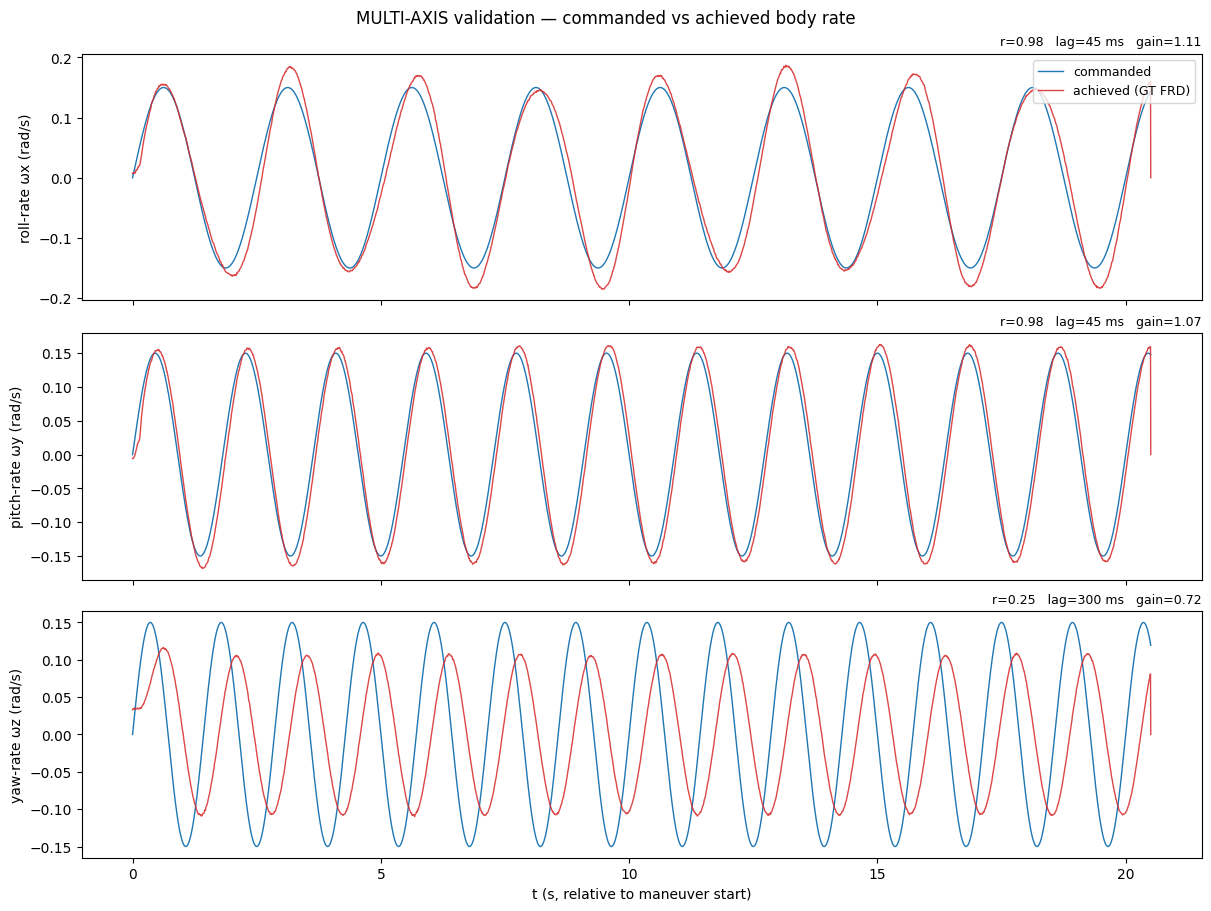

In [2]:
def validate_input(run, title):
    res = aic.per_run_metrics(run, return_series=True)
    if res is None:
        print(f'{title}: too few in-window samples — skip.'); return
    metrics, s = res
    t, cmd, tel = s['t'], s['cmd'], s['tel']
    print(f'=== {title} ===   {os.path.basename(run.rstrip("/"))}')
    print(f'  {"axis":14s} {"r":>6s} {"lag_ms":>8s} {"gain":>7s}')
    for ax in aic.AXES:
        m = metrics[ax]; print(f'  {AXLBL[ax]:14s} {m["r"]:6.2f} {m["lag_ms"]:8.1f} {m["gain"]:7.3f}')
    fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True, constrained_layout=True)
    for k, ax in enumerate(aic.AXES):
        a = axes[k]
        a.plot(t, cmd[:, k], color='C0', lw=1.0, label='commanded')
        a.plot(t, tel[:, k], color='C3', lw=1.0, alpha=0.85, label='achieved (GT FRD)')
        a.set_ylabel(f'{AXLBL[ax]} (rad/s)')
        m = metrics[ax]
        a.set_title(f'r={m["r"]:.2f}   lag={m["lag_ms"]:.0f} ms   gain={m["gain"]:.2f}',
                    fontsize=9, loc='right')
        if k == 0: a.legend(loc='upper right', fontsize=9)
    axes[-1].set_xlabel('t (s, relative to maneuver start)')
    fig.suptitle(f'{title} — commanded vs achieved body rate', fontsize=12)
    plt.show()

if MULTI_RUN:
    validate_input(MULTI_RUN, 'MULTI-AXIS validation')
else:
    print('No multi-axis validation run found.')

## 2 — Landing-to-touchdown validation

Same gain/lag check on a real landing's command stream — the operating regime. (Skips cleanly
if the recording lacks the `Command` / `Angular Velocity FRD` telemetry the metric needs.)

=== LANDING validation ===   Sun Jun  7 00-08-38 2026
  axis                r   lag_ms    gain
  roll-rate ωx     0.00      0.0   0.000
  pitch-rate ωy    0.03      0.0   0.000
  yaw-rate ωz     -0.05      0.0  -0.000


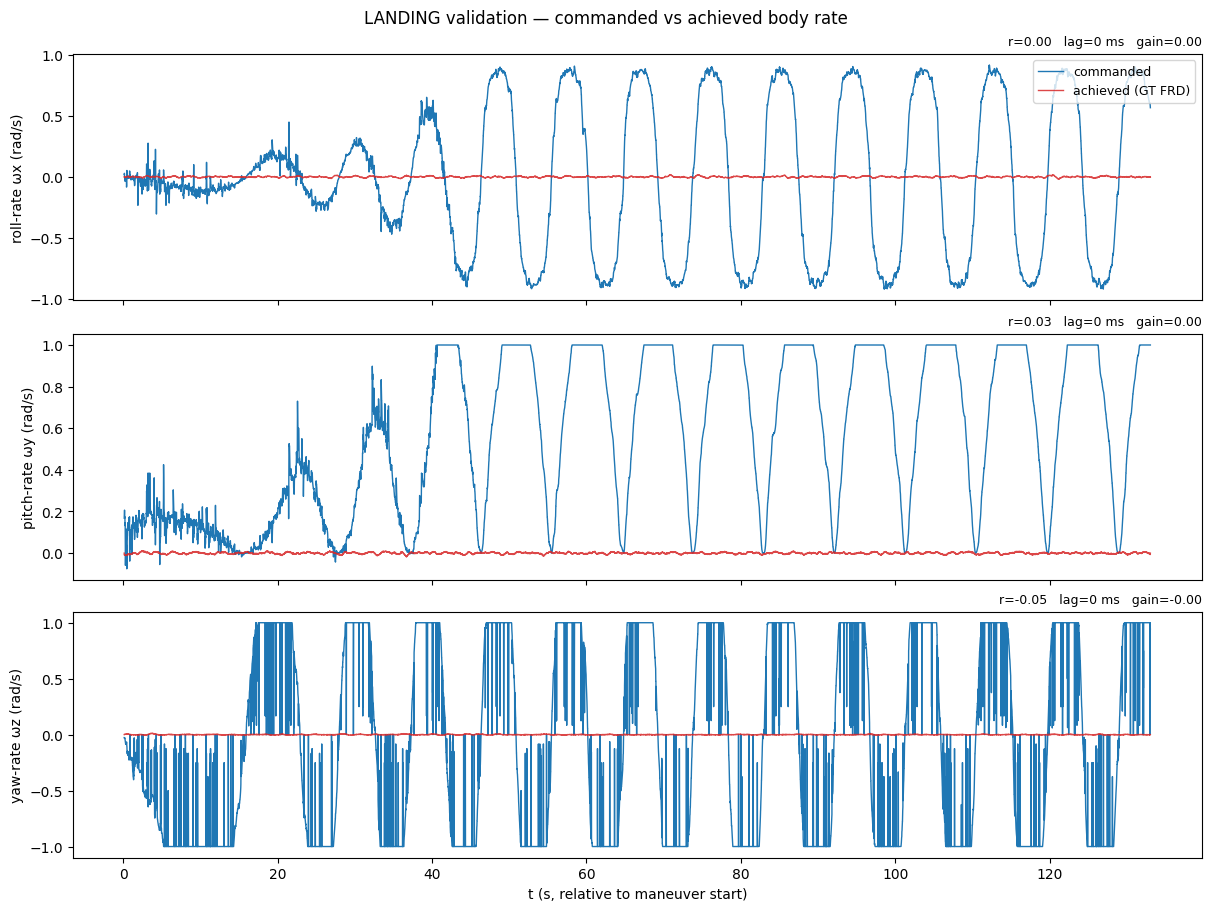

In [3]:
if LANDING_RUN:
    try:
        validate_input(LANDING_RUN, 'LANDING validation')
    except (KeyError, FileNotFoundError) as e:
        print(f'Landing run not compatible with the input metric ({e}).')
else:
    print('No landing run found.')